## GRACE Training Notebook


In [1]:
from __future__ import annotations

import inspect
import json
import random
from pathlib import Path
from typing import Dict, List

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    )
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoModelForSequenceClassification, Trainer, TrainingArguments

from pipeline_common import ensure_dir, read_jsonl

sns.set_theme(style="whitegrid", context="talk")

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "artifacts" / "features").exists():
        return cwd
    if (cwd.parent / "data" / "artifacts" / "features").exists():
        return cwd.parent
    return cwd

PROJECT_ROOT = resolve_project_root()
FEATURES_DIR = PROJECT_ROOT / "data" / "artifacts" / "features"
MODEL_DIR = PROJECT_ROOT / "model"
INDEX_DIR = PROJECT_ROOT / "index"
EVAL_DIR = PROJECT_ROOT / "eval"
FINAL_MODEL_DIR = MODEL_DIR / "final_model"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FEATURES_DIR exists: {FEATURES_DIR.exists()}")

PROJECT_ROOT: C:\Users\Admin\Documents\1. UET\lab\VulGuardVN\GRACE-java
FEATURES_DIR exists: True


## Utilities

In [2]:
DEFAULT_MODEL = "microsoft/graphcodebert-base"

SEED = 42
EPOCHS = 3
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
TOPK = 10
EMB_BATCH_SIZE = 16

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

class NumpyDataset(torch.utils.data.Dataset):
    def __init__(self, input_ids: np.ndarray, attention_mask: np.ndarray, labels: np.ndarray):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

def load_split(features_dir: Path, split: str) -> NumpyDataset:
    input_ids = np.load(features_dir / f"{split}.input_ids.npy")
    attention_mask = np.load(features_dir / f"{split}.attention_mask.npy")
    labels = np.load(features_dir / f"{split}.labels.npy")
    return NumpyDataset(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = np.argmax(logits, axis=-1)
    out = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }
    if len(np.unique(labels)) > 1:
        out["roc_auc"] = roc_auc_score(labels, probs)
    else:
        out["roc_auc"] = 0.0
    return out

def save_predictions(trainer: Trainer, dataset: NumpyDataset, split: str, out_dir: Path) -> None:
    pred_output = trainer.predict(dataset)
    logits = pred_output.predictions
    labels = pred_output.label_ids
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = np.argmax(logits, axis=-1)
    np.save(out_dir / f"{split}.logits.npy", logits)
    np.save(out_dir / f"{split}.labels.npy", labels)
    np.save(out_dir / f"{split}.probs.npy", probs)
    np.save(out_dir / f"{split}.preds.npy", preds)

def build_training_args(output_dir: Path) -> TrainingArguments:
    init_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    kwargs = {
        "output_dir": str(output_dir / "checkpoints"),
        "seed": SEED,
        "num_train_epochs": EPOCHS,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "logging_dir": str(output_dir / "logs"),
        "logging_steps": 20,
        "report_to": "none",
        "save_total_limit": 2,
    }
    if "overwrite_output_dir" in init_params:
        kwargs["overwrite_output_dir"] = True
    if "evaluation_strategy" in init_params:
        kwargs["evaluation_strategy"] = "epoch"
    elif "eval_strategy" in init_params:
        kwargs["eval_strategy"] = "epoch"
    if "save_strategy" in init_params:
        kwargs["save_strategy"] = "epoch"
    filtered_kwargs = {k: v for k, v in kwargs.items() if k in init_params}
    return TrainingArguments(**filtered_kwargs)

def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

def export_embeddings(features_dir: Path, model_dir: Path, out_dir: Path, batch_size: int = 16) -> None:
    ensure_dir(out_dir)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModel.from_pretrained(str(model_dir))
    model.to(device)
    model.eval()
    for split in ["train", "valid", "test"]:
        input_ids = np.load(features_dir / f"{split}.input_ids.npy")
        attention_mask = np.load(features_dir / f"{split}.attention_mask.npy")
        dataset = TensorDataset(
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(attention_mask, dtype=torch.long),
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        vectors = []
        with torch.no_grad():
            for batch in loader:
                ids, mask = [x.to(device) for x in batch]
                outputs = model(input_ids=ids, attention_mask=mask)
                pooled = mean_pool(outputs.last_hidden_state, mask)
                vectors.append(pooled.cpu().numpy())
        emb = np.concatenate(vectors, axis=0)
        np.save(out_dir / f"{split}.emb.npy", emb)
    with (out_dir / "embedding_config.json").open("w", encoding="utf-8") as f:
        json.dump(
            {
                "source_model": str(model_dir),
                "splits": ["train", "valid", "test"],
                "pooling": "mean_pool_last_hidden_state",
            },
            f,
            ensure_ascii=False,
            indent=2,
        )

def evaluate_binary(labels: np.ndarray, preds: np.ndarray, probs: np.ndarray) -> Dict:
    result = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(labels, preds).tolist(),
        "classification_report": classification_report(labels, preds, zero_division=0, output_dict=True),
    }
    if len(np.unique(labels)) > 1:
        result["roc_auc"] = float(roc_auc_score(labels, probs))
    else:
        result["roc_auc"] = 0.0
    return result

def evaluate_retrieval(test_meta: List[Dict], test_emb: np.ndarray, topk: int) -> Dict:
    labels = np.array([row["label"] for row in test_meta], dtype=np.int64)
    vuln_idx = np.where(labels == 1)[0]
    fixed_idx = np.where(labels == 0)[0]
    if len(vuln_idx) == 0 or len(fixed_idx) == 0:
        return {"error": "Need both vulnerable and fixed samples in test split."}
    fixed_emb = test_emb[fixed_idx].astype(np.float32)
    faiss.normalize_L2(fixed_emb)
    index = faiss.IndexFlatIP(fixed_emb.shape[1])
    index.add(fixed_emb)
    recalls = []
    rr_scores = []
    fixed_pair_ids = [test_meta[i]["pair_id"] for i in fixed_idx]
    for q in vuln_idx:
        q_vec = test_emb[q:q + 1].astype(np.float32)
        faiss.normalize_L2(q_vec)
        _, nn = index.search(q_vec, topk)
        gt_pair = test_meta[q]["pair_id"]
        retrieved_pairs = [fixed_pair_ids[r] for r in nn[0] if 0 <= r < len(fixed_pair_ids)]
        hit = gt_pair in retrieved_pairs
        recalls.append(1.0 if hit else 0.0)
        rr = 0.0
        for rank, pair_id in enumerate(retrieved_pairs, start=1):
            if pair_id == gt_pair:
                rr = 1.0 / rank
                break
        rr_scores.append(rr)
    return {
        "num_queries": len(vuln_idx),
        "num_candidates": len(fixed_idx),
        f"recall@{topk}": float(np.mean(recalls)) if recalls else 0.0,
        "mrr": float(np.mean(rr_scores)) if rr_scores else 0.0,
    }

def log_history_to_df(log_history: List[Dict]) -> pd.DataFrame:
    return pd.DataFrame(log_history)

## Train Classifier

In [3]:
set_seed(SEED)
ensure_dir(MODEL_DIR)

train_ds = load_split(FEATURES_DIR, "train")
valid_ds = load_split(FEATURES_DIR, "valid")
test_ds = load_split(FEATURES_DIR, "test")

model = AutoModelForSequenceClassification.from_pretrained(DEFAULT_MODEL, num_labels=2)
training_args = build_training_args(MODEL_DIR)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    )

train_output = trainer.train()
trainer.save_model(str(FINAL_MODEL_DIR))

valid_metrics = trainer.evaluate(valid_ds)
test_metrics = trainer.evaluate(test_ds)

save_predictions(trainer, valid_ds, "valid", MODEL_DIR)
save_predictions(trainer, test_ds, "test", MODEL_DIR)

with (MODEL_DIR / "metrics.json").open("w", encoding="utf-8") as f:
    json.dump({"valid": valid_metrics, "test": test_metrics}, f, ensure_ascii=False, indent=2)

log_history_df = log_history_to_df(trainer.state.log_history)

print(json.dumps({"valid": valid_metrics, "test": test_metrics}, ensure_ascii=False, indent=2))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.680665,0.713023,0.500000,0.500000,0.053333,0.096386,0.528267
2,0.663867,0.709542,0.520000,0.515152,0.680000,0.586207,0.524711
3,0.655521,0.700099,0.513333,0.507692,0.880000,0.643902,0.538044


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "valid": {
    "eval_loss": 0.7000987529754639,
    "eval_accuracy": 0.5133333333333333,
    "eval_precision": 0.5076923076923077,
    "eval_recall": 0.88,
    "eval_f1": 0.6439024390243903,
    "eval_roc_auc": 0.5380444444444445,
    "eval_runtime": 2.5899,
    "eval_samples_per_second": 57.917,
    "eval_steps_per_second": 7.336,
    "epoch": 3.0
  },
  "test": {
    "eval_loss": 0.7349674105644226,
    "eval_accuracy": 0.5163934426229508,
    "eval_precision": 0.5104166666666666,
    "eval_recall": 0.8032786885245902,
    "eval_f1": 0.6242038216560509,
    "eval_roc_auc": 0.5166621875839829,
    "eval_runtime": 2.133,
    "eval_samples_per_second": 57.196,
    "eval_steps_per_second": 7.501,
    "epoch": 3.0
  }
}


## Export Embeddings

In [4]:
export_embeddings(FEATURES_DIR, FINAL_MODEL_DIR, INDEX_DIR, batch_size=EMB_BATCH_SIZE)
print(f"Embeddings saved to: {INDEX_DIR}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: C:\Users\Admin\Documents\1. UET\lab\VulGuardVN\GRACE-java\model\final_model
Key                        | Status     | 
---------------------------+------------+-
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
pooler.dense.weight        | MISSING    | 
pooler.dense.bias          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Embeddings saved to: C:\Users\Admin\Documents\1. UET\lab\VulGuardVN\GRACE-java\index


## Evaluate Classification And Retrieval

In [5]:
ensure_dir(EVAL_DIR)

test_labels = np.load(MODEL_DIR / "test.labels.npy")
test_preds = np.load(MODEL_DIR / "test.preds.npy")
test_probs = np.load(MODEL_DIR / "test.probs.npy")

binary_metrics = evaluate_binary(test_labels, test_preds, test_probs)

test_meta = read_jsonl(FEATURES_DIR / "test.meta.jsonl")
test_emb = np.load(INDEX_DIR / "test.emb.npy")
retrieval_metrics = evaluate_retrieval(test_meta, test_emb, TOPK)

with (EVAL_DIR / "metrics_binary.json").open("w", encoding="utf-8") as f:
    json.dump(binary_metrics, f, ensure_ascii=False, indent=2)

with (EVAL_DIR / "metrics_retrieval.json").open("w", encoding="utf-8") as f:
    json.dump(retrieval_metrics, f, ensure_ascii=False, indent=2)

print(json.dumps({"binary": binary_metrics, "retrieval": retrieval_metrics}, ensure_ascii=False, indent=2))

{
  "binary": {
    "accuracy": 0.5163934426229508,
    "precision": 0.5104166666666666,
    "recall": 0.8032786885245902,
    "f1": 0.6242038216560509,
    "confusion_matrix": [
      [
        14,
        47
      ],
      [
        12,
        49
      ]
    ],
    "classification_report": {
      "0": {
        "precision": 0.5384615384615384,
        "recall": 0.22950819672131148,
        "f1-score": 0.3218390804597701,
        "support": 61.0
      },
      "1": {
        "precision": 0.5104166666666666,
        "recall": 0.8032786885245902,
        "f1-score": 0.6242038216560509,
        "support": 61.0
      },
      "accuracy": 0.5163934426229508,
      "macro avg": {
        "precision": 0.5244391025641025,
        "recall": 0.5163934426229508,
        "f1-score": 0.4730214510579105,
        "support": 122.0
      },
      "weighted avg": {
        "precision": 0.5244391025641025,
        "recall": 0.5163934426229508,
        "f1-score": 0.4730214510579105,
        "support":

## Visualize Training And Evaluation

In [6]:
def plot_training_curves(df: pd.DataFrame) -> None:
    _, axes = plt.subplots(1, 2, figsize=(18, 6))

    if "loss" in df.columns:
        train_df = df[df["loss"].notna()].copy()
        if not train_df.empty:
            axes[0].plot(train_df["step"], train_df["loss"], marker="o", label="train_loss")
    if "eval_loss" in df.columns:
        eval_df = df[df["eval_loss"].notna()].copy()
        if not eval_df.empty:
            axes[0].plot(eval_df["epoch"], eval_df["eval_loss"], marker="s", label="eval_loss")
    axes[0].set_title("Training vs Validation Loss")
    axes[0].set_xlabel("Step / Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    if "eval_f1" in df.columns:
        eval_f1_df = df[df["eval_f1"].notna()].copy()
        if not eval_f1_df.empty:
            axes[1].plot(eval_f1_df["epoch"], eval_f1_df["eval_f1"], marker="o", color="#D62728", label="eval_f1")
    if "eval_accuracy" in df.columns:
        eval_acc_df = df[df["eval_accuracy"].notna()].copy()
        if not eval_acc_df.empty:
            axes[1].plot(eval_acc_df["epoch"], eval_acc_df["eval_accuracy"], marker="s", color="#1F77B4", label="eval_accuracy")
    axes[1].set_title("Validation Metrics By Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_confusion(labels: np.ndarray, preds: np.ndarray) -> None:
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def plot_binary_metric_bars(metrics: Dict) -> None:
    keys = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    vals = [metrics.get(k, 0.0) for k in keys]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=keys, y=vals, palette="viridis")
    plt.ylim(0, 1.05)
    plt.title("Binary Classification Metrics")
    plt.ylabel("Score")
    plt.xlabel("")
    plt.show()

def plot_roc_pr(labels: np.ndarray, probs: np.ndarray) -> None:
    if len(np.unique(labels)) < 2:
        return
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(labels, probs)
    ap = average_precision_score(labels, probs)

    _, axes = plt.subplots(1, 2, figsize=(16, 6))
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=axes[0])
    axes[0].set_title("ROC Curve")

    PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap).plot(ax=axes[1])
    axes[1].set_title("Precision-Recall Curve")

    plt.tight_layout()
    plt.show()

def plot_retrieval_metrics(metrics: Dict, topk: int) -> None:
    recall_key = f"recall@{topk}"
    keys = [recall_key, "mrr"]
    vals = [metrics.get(recall_key, 0.0), metrics.get("mrr", 0.0)]
    plt.figure(figsize=(8, 6))
    sns.barplot(x=keys, y=vals, palette=["#2CA02C", "#FF7F0E"])
    plt.ylim(0, 1.05)
    plt.title("Retrieval Metrics")
    plt.ylabel("Score")
    plt.xlabel("")
    plt.show()

## Plot Results

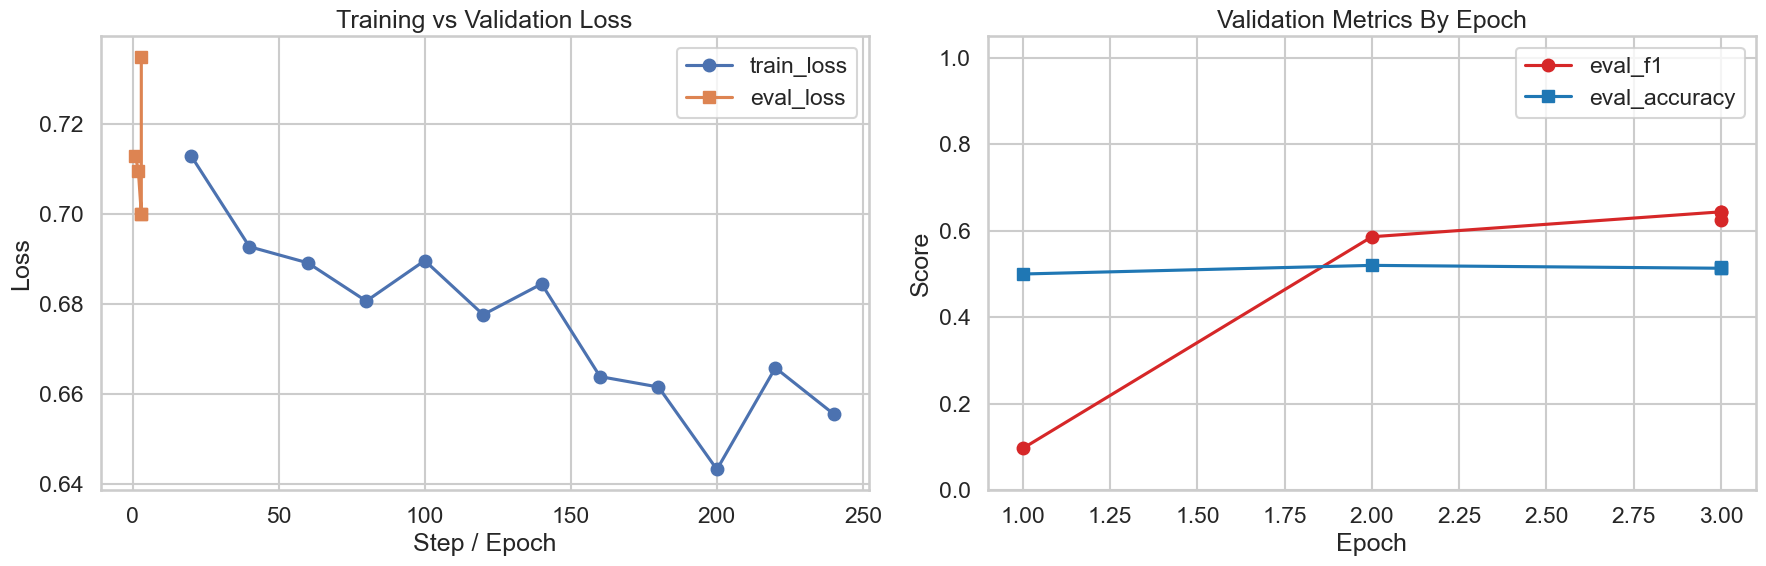

C:\Users\Admin\AppData\Local\Temp\ipykernel_9768\1832640352.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keys, y=vals, palette="viridis")


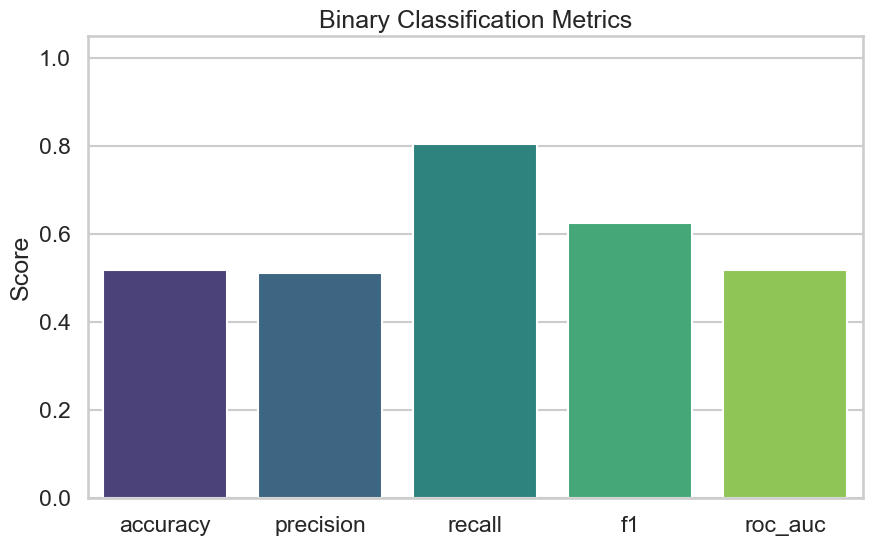

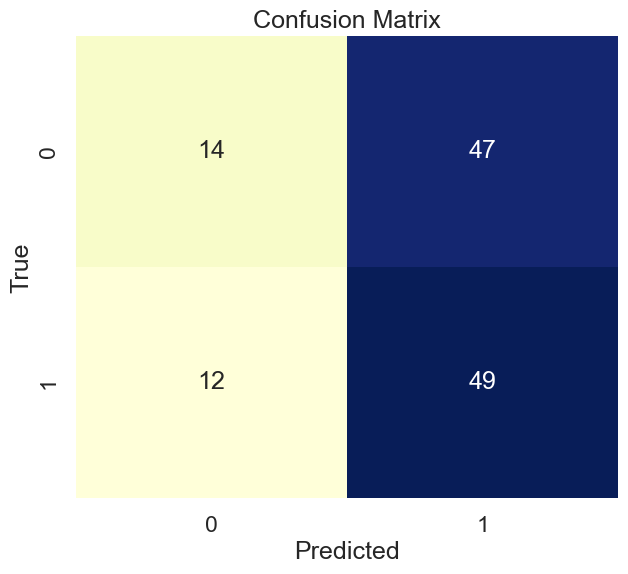

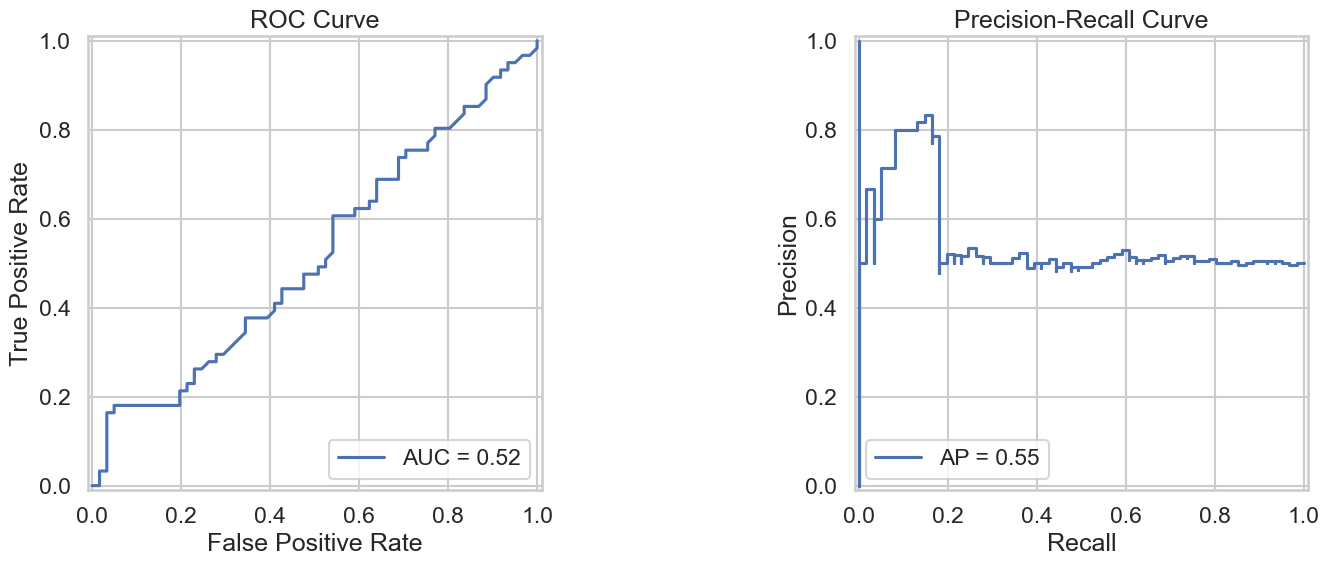

C:\Users\Admin\AppData\Local\Temp\ipykernel_9768\1832640352.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keys, y=vals, palette=["#2CA02C", "#FF7F0E"])


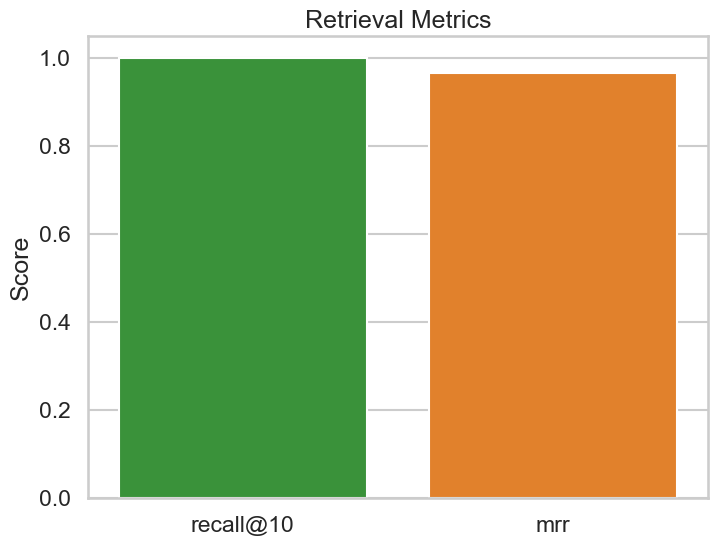

,split,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,valid,0.700099,0.513333,0.507692,0.880000,0.643902,0.538044,2.5899,57.917,7.336,3.0
1,test,0.734967,0.516393,0.510417,0.803279,0.624204,0.516662,2.1330,57.196,7.501,3.0


,accuracy,precision,recall,f1,confusion_matrix,classification_report,roc_auc
0,0.516393,0.510417,0.803279,0.624204,"[[14, 47], [12, 49]]","{'0': {'precision': 0.5384615384615384, 'recal...",0.516662


,num_queries,num_candidates,recall@10,mrr
0,61,61,1.0,0.964481


In [7]:
plot_training_curves(log_history_df)
plot_binary_metric_bars(binary_metrics)
plot_confusion(test_labels, test_preds)
plot_roc_pr(test_labels, test_probs)
plot_retrieval_metrics(retrieval_metrics, TOPK)

display(pd.DataFrame([
    {"split": "valid", **{k: v for k, v in valid_metrics.items() if isinstance(v, (int, float))}},
    {"split": "test", **{k: v for k, v in test_metrics.items() if isinstance(v, (int, float))}},
]))

display(pd.DataFrame([binary_metrics]))
display(pd.DataFrame([retrieval_metrics]))